<a href="https://colab.research.google.com/github/joshualewin6/Colab-Notebook/blob/main/JoshLewiU8proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predicting Football Scores


##Intro
I'm once again trying to predict football scores, but in this model, instead of using previous scores as a predictors, I'm using yards, drives, first downs, and turnovers all in a BART model, utilizing a random forest. This is going to create a far better predictive model, and I'll check to see which variables have the greatest effects using ice plots, pdps, and other methods.

Alright, it's import time.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import arviz as az

In [2]:
!pip install pymc-bart

In [3]:
import pymc_bart as pmb

##The Data
Here's our data, there are 63 columns but we can ignore most of them on account of them obviously having little measurable effect on the score.

In [4]:
games = pd.read_csv('https://raw.githubusercontent.com/joshualewin6/Colab-Notebook/refs/heads/main/nflGames%20-%20goog4_request%26X-Goog-Date%3D20250327T190623Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D996c8d120169241401ad4a075dcf8aabf6ee025915c8fcac06ff8960120ff625433564ab9547b38925cbeeca48e19fae6cce66cdd4965fc3382487f65.csv')
games = games.dropna()
games

,season,week,date,time_et,neutral,away,home,score_away,score_home,first_downs_away,...,redzone_comp_home,redzone_att_home,fumbles_away,fumbles_home,interceptions_away,interceptions_home,def_st_td_away,def_st_td_home,possession_away,possession_home
0,2002,1,2002-09-05,8:30 PM,False,49ers,Giants,16,13,13,...,0,6,0,0,1,3,0,0,27:32:00,32:28:00
1,2002,1,2002-09-08,1:00 PM,False,Colts,Jaguars,28,25,18,...,0,8,2,1,0,1,2,0,27:27:00,32:33:00
2,2002,1,2002-09-08,1:00 PM,False,Cardinals,Commanders,23,31,14,...,0,8,0,0,1,1,0,0,25:36:00,34:24:00
3,2002,1,2002-09-08,1:00 PM,False,Lions,Dolphins,21,49,15,...,0,8,1,0,1,0,0,2,25:36:00,34:24:00
4,2002,1,2002-09-08,1:00 PM,False,Eagles,Titans,24,27,17,...,0,7,1,3,2,1,0,0,29:12:00,30:48:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6209,2024,Division,2025-01-19,3:00 PM,False,Rams,Eagles,22,28,18,...,0,2,2,0,0,0,0,0,29:06:00,30:54:00
6210,2024,Division,2025-01-19,6:30 PM,False,Ravens,Bills,25,27,23,...,3,4,2,0,1,0,0,0,28:16:00,31:44:00
6211,2024,Conference,2025-01-26,3:00 PM,False,Commanders,Eagles,23,55,22,...,7,7,3,0,1,0,0,0,29:29:00,30:31:00
6212,2024,Conference,2025-01-26,6:30 PM,False,Bills,Chiefs,29,32,22,...,4,6,0,1,0,0,0,0,30:32:00,29:28:00


These scatterplots show some of the general trends I expect to see, though they can't represent how all the variables appear.

<Axes: xlabel='yards_away', ylabel='score_away'>

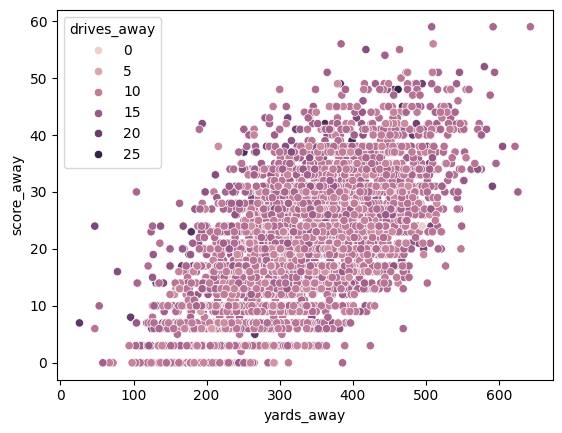

In [5]:
sns.scatterplot(data = games, y = 'score_away', x = 'yards_away', hue = 'drives_away')

<Axes: xlabel='yards_home', ylabel='score_home'>

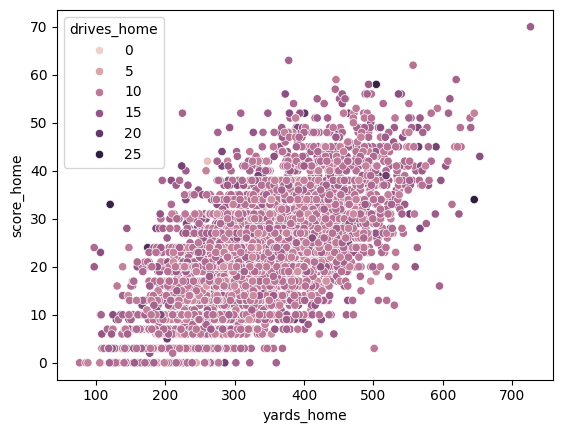

In [6]:
sns.scatterplot(data = games, y = 'score_home', x = 'yards_home', hue = 'drives_home')

##The Models
Now we're going to build two BART models, one for home teams, one for away. These models will incorporate all 8 variables that we're using, and after we can analyse which of them are having the greatest effect based on ice plots and the like.

In [14]:
#turn fummbles and interceptions into turnovers, they have the same outcome
games['turnovers_away']=games['fumbles_away']+games['interceptions_away']
games['turnovers_home']=games['fumbles_home']+games['interceptions_home']

I initially wanted to run only one model. The predicted variables would be an array, and my distribution would be something similar to a bivariate Gamma. This, admittedly, was a terrible idea. The Wishart distribution was the best thing I had available, and after experimenting with it for a bit, I learned it was only a theoretical distribution and has not been implemented into pymc. Instead, I've settled for two Gamma likelihoods.

In [15]:
X = games[['yards_home','drives_home','first_downs_home','turnovers_home','yards_away','drives_away','first_downs_away','turnovers_away',]]
Yh = games['score_home']
Ya = games['score_away']

In [19]:
with pm.Model() as model_home:
    μ_ = pmb.BART("μ_", X, np.log(Yh+0.00001), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_)-0.00001)
    s = pm.HalfNormal("s",12)
    y = pm.Gamma("y", mu=μ, sigma=s, observed=Yh+0.00001) #likelihood
    idata_home = pm.sample(compute_convergence_checks=False)

Output()

In [20]:
pm.sample_posterior_predictive(idata_home,model_home, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

array([<Axes: xlabel='yards_home'>, <Axes: xlabel='drives_home'>,
       <Axes: xlabel='first_downs_home'>, <Axes: xlabel='turnovers_home'>,
       <Axes: xlabel='yards_away'>, <Axes: xlabel='drives_away'>,
       <Axes: xlabel='first_downs_away'>, <Axes: xlabel='turnovers_away'>],
      dtype=object)

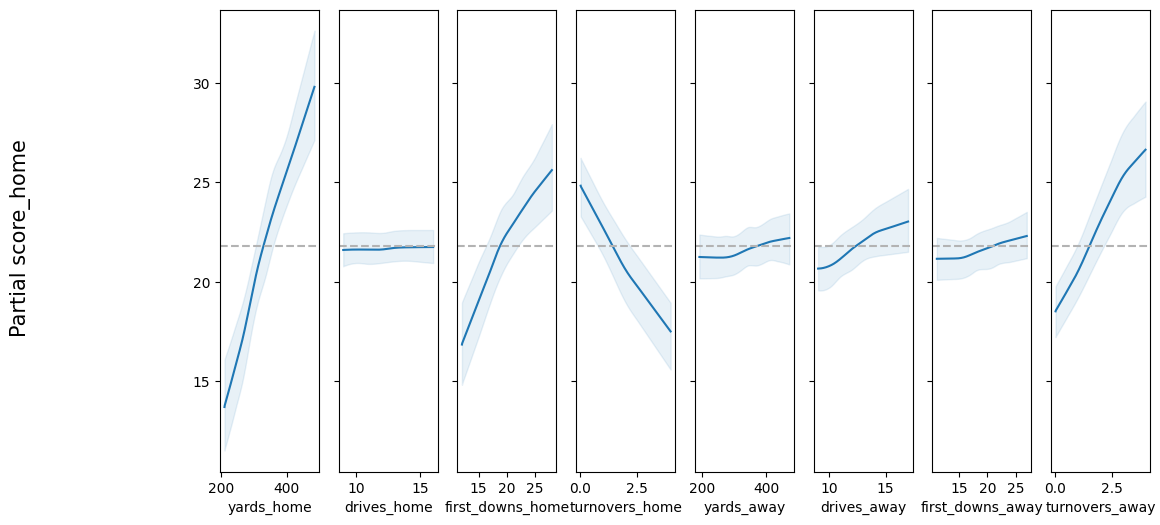

In [21]:
pmb.plot_pdp(μ_, X, Yh, grid=(1, 8), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='yards_home'>, <Axes: xlabel='drives_home'>,
       <Axes: xlabel='first_downs_home'>, <Axes: xlabel='turnovers_home'>,
       <Axes: xlabel='yards_away'>, <Axes: xlabel='drives_away'>,
       <Axes: xlabel='first_downs_away'>, <Axes: xlabel='turnovers_away'>],
      dtype=object)

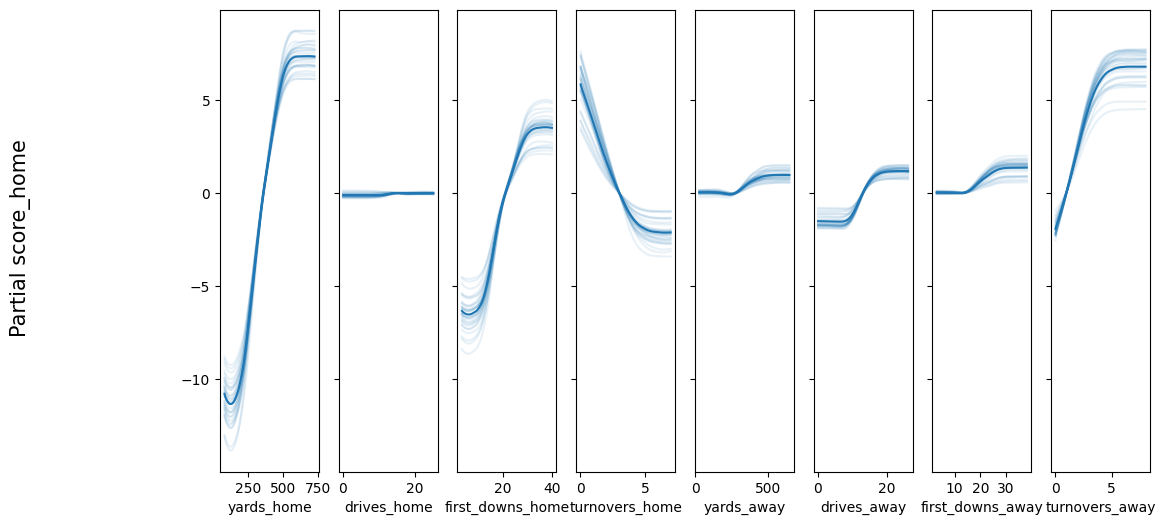

In [22]:
pmb.plot_ice( μ_, X, Yh, grid=(1, 8), func=np.exp, figsize = (12,6))

<Axes: ylabel='R²'>

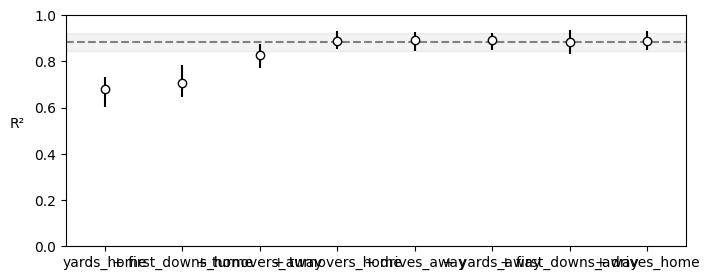

In [23]:
vi_home = pmb.compute_variable_importance(idata_home, μ_, X)
pmb.plot_variable_importance(vi_home, figsize=(12,6))

<Axes: xlabel='y'>

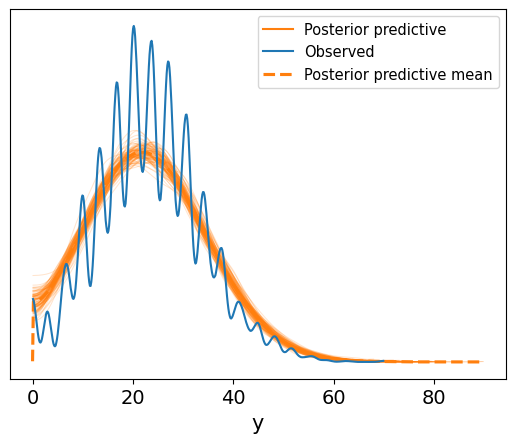

In [24]:
ax = az.plot_ppc(idata_home, num_pp_samples=100, colors=["C1", "C0", "C1"])
ax

In [25]:
with pm.Model() as model_away:
    μ_ = pmb.BART("μ_", X, np.log(Ya+0.00001), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_)-0.00001)
    s = pm.HalfNormal("s",12)
    y = pm.Gamma("y", mu=μ, sigma=s, observed=Ya+0.00001) #likelihood
    idata_away = pm.sample(compute_convergence_checks=False)

Output()

In [27]:
pm.sample_posterior_predictive(idata_away,model_away, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='y'>

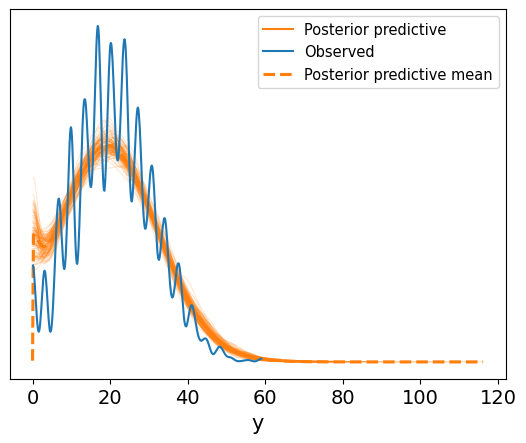

In [28]:
ay = az.plot_ppc(idata_away, num_pp_samples=100, colors=["C1", "C0", "C1"])
ay

array([<Axes: xlabel='yards_home'>, <Axes: xlabel='drives_home'>,
       <Axes: xlabel='first_downs_home'>, <Axes: xlabel='turnovers_home'>,
       <Axes: xlabel='yards_away'>, <Axes: xlabel='drives_away'>,
       <Axes: xlabel='first_downs_away'>, <Axes: xlabel='turnovers_away'>],
      dtype=object)

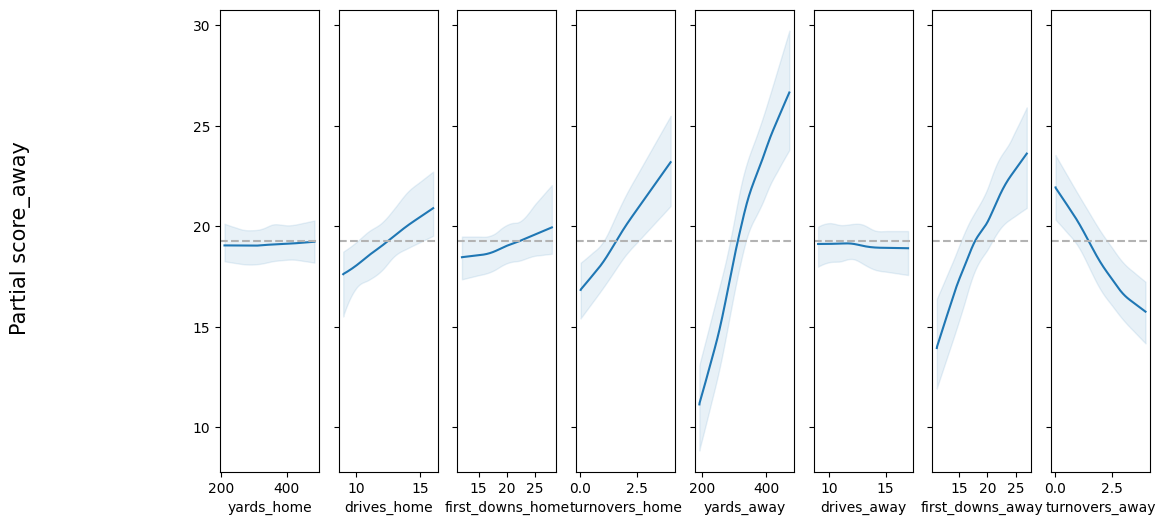

In [29]:
pmb.plot_pdp(μ_, X, Ya, grid=(1, 8), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='yards_home'>, <Axes: xlabel='drives_home'>,
       <Axes: xlabel='first_downs_home'>, <Axes: xlabel='turnovers_home'>,
       <Axes: xlabel='yards_away'>, <Axes: xlabel='drives_away'>,
       <Axes: xlabel='first_downs_away'>, <Axes: xlabel='turnovers_away'>],
      dtype=object)

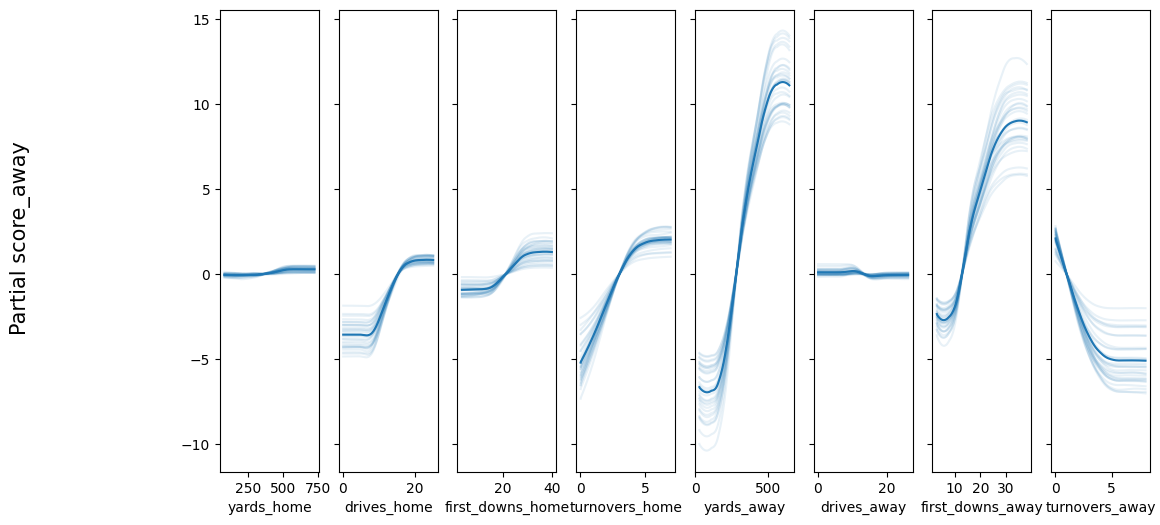

In [30]:
pmb.plot_ice( μ_, X, Ya, grid=(1, 8), func=np.exp, figsize = (12,6))

<Axes: ylabel='R²'>

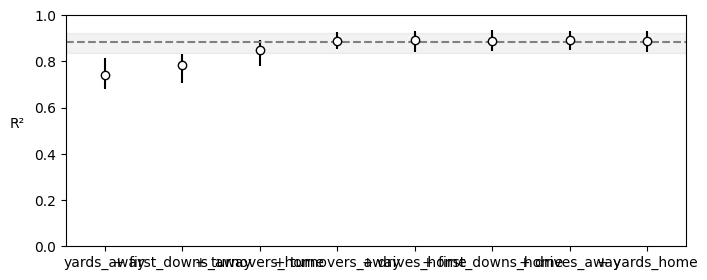

In [31]:
vi_away = pmb.compute_variable_importance(idata_away, μ_, X)
pmb.plot_variable_importance(vi_away)

##Conclusion
Overall, while the model misses the peaks and troughs apparent in the score distribution, the variables incorporated are mostly strong predictors in they expected way: yards have a strong positive affect, first downs and opposing turnovers, too, while a teams own turnovers are a negative predictor. The models arrived at something bizarre, though, which is the the number of drives a team has very definitively has no effect on their score whatsoever, and I can't think of why.

So, good model, but I'm still chasing the ever-elusive football model that predicts reasonable scores.